In [319]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [320]:
df_a = pd.read_csv('arkansas_partie2.csv')
df_c = pd.read_csv('california_partie2.csv')

In [321]:
df_a.info()
df_a.head()

<class 'pandas.DataFrame'>
RangeIndex: 9981 entries, 0 to 9980
Columns: 492 entries, system:index to .geo
dtypes: float64(468), int64(21), str(3)
memory usage: 37.5 MB


,system:index,B11_T0,B11_T1,B11_T10,B11_T11,B11_T12,B11_T13,B11_T14,B11_T15,B11_T16,...,tmin_27,tmin_28,tmin_29,tmin_30,tmin_31,tmin_32,tmin_33,tmin_34,tmin_35,.geo
0,00000000000000000002_0,3493.0,3742.0,4504.0,3782.0,4722.5,5072.0,5876.0,0.0,2652.0,...,17.593515,9.598047,10.387583,3.482919,3.987588,1.064722,3.048181,2.509515,-0.625510,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,00000000000000000004_0,3232.0,3589.0,5048.0,3738.0,4531.5,4309.0,2739.5,0.0,2602.5,...,17.365000,9.328516,9.948862,3.222497,4.493448,1.713159,3.000497,2.130868,-0.775900,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,00000000000000000007_0,3499.0,3990.0,4514.0,4063.0,5600.5,6008.0,6418.5,4066.0,3660.0,...,17.540781,9.851954,10.366831,3.945154,4.239541,1.224878,2.921228,2.367197,-0.576681,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0000000000000000000a_0,2721.5,3163.5,3634.5,3211.0,3143.0,3247.5,5531.5,0.0,3346.5,...,17.263437,9.744532,10.453989,3.500497,3.118448,0.078394,3.202478,1.546289,-0.656760,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0000000000000000000d_0,3124.5,3498.0,6004.0,3654.0,4527.5,4171.0,3841.0,0.0,2922.0,...,17.808360,11.625879,10.461802,4.783701,5.389932,2.385034,3.502451,2.999414,1.440897,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [322]:
print(df_a.columns.tolist())

['system:index', 'B11_T0', 'B11_T1', 'B11_T10', 'B11_T11', 'B11_T12', 'B11_T13', 'B11_T14', 'B11_T15', 'B11_T16', 'B11_T17', 'B11_T18', 'B11_T19', 'B11_T2', 'B11_T20', 'B11_T21', 'B11_T22', 'B11_T23', 'B11_T24', 'B11_T25', 'B11_T26', 'B11_T27', 'B11_T28', 'B11_T29', 'B11_T3', 'B11_T30', 'B11_T31', 'B11_T32', 'B11_T33', 'B11_T34', 'B11_T35', 'B11_T4', 'B11_T5', 'B11_T6', 'B11_T7', 'B11_T8', 'B11_T9', 'B12_T0', 'B12_T1', 'B12_T10', 'B12_T11', 'B12_T12', 'B12_T13', 'B12_T14', 'B12_T15', 'B12_T16', 'B12_T17', 'B12_T18', 'B12_T19', 'B12_T2', 'B12_T20', 'B12_T21', 'B12_T22', 'B12_T23', 'B12_T24', 'B12_T25', 'B12_T26', 'B12_T27', 'B12_T28', 'B12_T29', 'B12_T3', 'B12_T30', 'B12_T31', 'B12_T32', 'B12_T33', 'B12_T34', 'B12_T35', 'B12_T4', 'B12_T5', 'B12_T6', 'B12_T7', 'B12_T8', 'B12_T9', 'B2_T0', 'B2_T1', 'B2_T10', 'B2_T11', 'B2_T12', 'B2_T13', 'B2_T14', 'B2_T15', 'B2_T16', 'B2_T17', 'B2_T18', 'B2_T19', 'B2_T2', 'B2_T20', 'B2_T21', 'B2_T22', 'B2_T23', 'B2_T24', 'B2_T25', 'B2_T26', 'B2_T27', 'B2_

In [323]:
print('Arkansas - Distribution des classes:')
print(df_a['crop_name'].value_counts())

Arkansas - Distribution des classes:
crop_name
Soybeans    4680
Rice        2341
Corn        1501
Cotton       794
Others       665
Name: count, dtype: int64


In [324]:
print('California - Distribution des classes:')
print(df_c['crop_name'].value_counts())

California - Distribution des classes:
crop_name
Others        3580
Rice          2021
Grapes        2010
Alfalfa        964
Almonds        793
Pistachios     628
Name: count, dtype: int64


In [325]:
nouvel_ordre = [
    'B2_T0','B3_T0','B4_T0','B5_T0','B6_T0','B7_T0','B8_T0','B8A_T0','B11_T0','B12_T0',
    'B2_T1','B3_T1','B4_T1','B5_T1','B6_T1','B7_T1','B8_T1','B8A_T1','B11_T1','B12_T1',
    'B2_T2','B3_T2','B4_T2','B5_T2','B6_T2','B7_T2','B8_T2','B8A_T2','B11_T2','B12_T2',
    'B2_T3','B3_T3','B4_T3','B5_T3','B6_T3','B7_T3','B8_T3','B8A_T3','B11_T3','B12_T3',
    'B2_T4','B3_T4','B4_T4','B5_T4','B6_T4','B7_T4','B8_T4','B8A_T4','B11_T4','B12_T4',
    'B2_T5','B3_T5','B4_T5','B5_T5','B6_T5','B7_T5','B8_T5','B8A_T5','B11_T5','B12_T5',
    'B2_T6','B3_T6','B4_T6','B5_T6','B6_T6','B7_T6','B8_T6','B8A_T6','B11_T6','B12_T6',
    'B2_T7','B3_T7','B4_T7','B5_T7','B6_T7','B7_T7','B8_T7','B8A_T7','B11_T7','B12_T7',
    'B2_T8','B3_T8','B4_T8','B5_T8','B6_T8','B7_T8','B8_T8','B8A_T8','B11_T8','B12_T8',
    'B2_T9','B3_T9','B4_T9','B5_T9','B6_T9','B7_T9','B8_T9','B8A_T9','B11_T9','B12_T9',
    'B2_T10','B3_T10','B4_T10','B5_T10','B6_T10','B7_T10','B8_T10','B8A_T10','B11_T10','B12_T10',
    'B2_T11','B3_T11','B4_T11','B5_T11','B6_T11','B7_T11','B8_T11','B8A_T11','B11_T11','B12_T11',
    'B2_T12','B3_T12','B4_T12','B5_T12','B6_T12','B7_T12','B8_T12','B8A_T12','B11_T12','B12_T12',
    'B2_T13','B3_T13','B4_T13','B5_T13','B6_T13','B7_T13','B8_T13','B8A_T13','B11_T13','B12_T13',
    'B2_T14','B3_T14','B4_T14','B5_T14','B6_T14','B7_T14','B8_T14','B8A_T14','B11_T14','B12_T14',
    'B2_T15','B3_T15','B4_T15','B5_T15','B6_T15','B7_T15','B8_T15','B8A_T15','B11_T15','B12_T15',
    'B2_T16','B3_T16','B4_T16','B5_T16','B6_T16','B7_T16','B8_T16','B8A_T16','B11_T16','B12_T16',
    'B2_T17','B3_T17','B4_T17','B5_T17','B6_T17','B7_T17','B8_T17','B8A_T17','B11_T17','B12_T17',
    'B2_T18','B3_T18','B4_T18','B5_T18','B6_T18','B7_T18','B8_T18','B8A_T18','B11_T18','B12_T18',
    'B2_T19','B3_T19','B4_T19','B5_T19','B6_T19','B7_T19','B8_T19','B8A_T19','B11_T19','B12_T19',
    'B2_T20','B3_T20','B4_T20','B5_T20','B6_T20','B7_T20','B8_T20','B8A_T20','B11_T20','B12_T20',
    'B2_T21','B3_T21','B4_T21','B5_T21','B6_T21','B7_T21','B8_T21','B8A_T21','B11_T21','B12_T21',
    'B2_T22','B3_T22','B4_T22','B5_T22','B6_T22','B7_T22','B8_T22','B8A_T22','B11_T22','B12_T22',
    'B2_T23','B3_T23','B4_T23','B5_T23','B6_T23','B7_T23','B8_T23','B8A_T23','B11_T23','B12_T23',
    'B2_T24','B3_T24','B4_T24','B5_T24','B6_T24','B7_T24','B8_T24','B8A_T24','B11_T24','B12_T24',
    'B2_T25','B3_T25','B4_T25','B5_T25','B6_T25','B7_T25','B8_T25','B8A_T25','B11_T25','B12_T25',
    'B2_T26','B3_T26','B4_T26','B5_T26','B6_T26','B7_T26','B8_T26','B8A_T26','B11_T26','B12_T26',
    'B2_T27','B3_T27','B4_T27','B5_T27','B6_T27','B7_T27','B8_T27','B8A_T27','B11_T27','B12_T27',
    'B2_T28','B3_T28','B4_T28','B5_T28','B6_T28','B7_T28','B8_T28','B8A_T28','B11_T28','B12_T28',
    'B2_T29','B3_T29','B4_T29','B5_T29','B6_T29','B7_T29','B8_T29','B8A_T29','B11_T29','B12_T29',
    'B2_T30','B3_T30','B4_T30','B5_T30','B6_T30','B7_T30','B8_T30','B8A_T30','B11_T30','B12_T30',
    'B2_T31','B3_T31','B4_T31','B5_T31','B6_T31','B7_T31','B8_T31','B8A_T31','B11_T31','B12_T31',
    'B2_T32','B3_T32','B4_T32','B5_T32','B6_T32','B7_T32','B8_T32','B8A_T32','B11_T32','B12_T32',
    'B2_T33','B3_T33','B4_T33','B5_T33','B6_T33','B7_T33','B8_T33','B8A_T33','B11_T33','B12_T33',
    'B2_T34','B3_T34','B4_T34','B5_T34','B6_T34','B7_T34','B8_T34','B8A_T34','B11_T34','B12_T34',
    'B2_T35','B3_T35','B4_T35','B5_T35','B6_T35','B7_T35','B8_T35','B8A_T35','B11_T35','B12_T35',

    'crop_label',

    'soc_0-5cm_mean', 'soc_5-15cm_mean',
      'phh2o_15-30cm_mean',
    'clay_0-5cm_mean','clay_30-60cm_mean',

    'crop_name'
]

df_a = df_a[nouvel_ordre]
df_c = df_c[nouvel_ordre]




## Arkansas — S2 + Sol

In [326]:
# Séparer X et y
df_a_x = df_a.drop(columns=['crop_label', 'crop_name'])
df_a_y = df_a[['crop_name', 'crop_label']].copy()
df_a_y.loc[df_a['crop_name'] == 'Others', 'crop_label'] = 0
df_a_y.loc[df_a['crop_label'] == 5, 'crop_label'] = 4
y_a = df_a_y['crop_label'].values

In [327]:
# Reshape X_time
X_time_a = df_a_x[[col for col in df_a_x.columns if '_T' in col and col.startswith('B')]].values
X_time_a = X_time_a.reshape(-1, 36, 10)

# Sol uniquement : SOC + pH + Clay 
soil_cols = [
    'soc_0-5cm_mean',
      'phh2o_15-30cm_mean',
    'clay_30-60cm_mean'
]
X_static_a = df_a_x[soil_cols].values

print('X_time shape:', X_time_a.shape)    # (N, 36, 10)
print('X_static shape:', X_static_a.shape) # (N, 18)


X_time shape: (9981, 36, 10)
X_static shape: (9981, 3)


In [328]:
mask_time_a = (X_time_a != 0).astype(float)

In [329]:
X_max = X_time_a.max(axis=(0, 1), keepdims=True)

with np.errstate(invalid='ignore', divide='ignore'):
    X_time = np.where(
        X_max == 0,
        0,
        X_time_a / X_max
    )

# normalisation statique
X_static_max = X_static_a.max(axis=0, keepdims=True)

with np.errstate(invalid='ignore', divide='ignore'):
    X_static_a = np.where(
        X_static_max == 0,
        0,
        X_static_a / X_static_max
    )

In [330]:
# Split Arkansas — stratifié par classe (300 échantillons/classe pour train+val)

def split_par_classe(df, X_time, X_static, y, mask, n_per_class=300, val_ratio=0.2, random_state=42):
    train_idx, val_idx, test_idx = [], [], []

    for classe in np.unique(y):
        idx_classe = np.where(y == classe)[0]
        idx_trainval, idx_test = train_test_split(
            idx_classe, train_size=n_per_class,
            random_state=random_state, shuffle=True
        )
        idx_train, idx_val = train_test_split(
            idx_trainval, test_size=val_ratio,
            random_state=random_state, shuffle=True
        )
        train_idx.extend(idx_train)
        val_idx.extend(idx_val)
        test_idx.extend(idx_test)

    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx)
    test_idx  = np.array(test_idx)

    return (
        X_time[train_idx],   X_time[val_idx],   X_time[test_idx],
        X_static[train_idx], X_static[val_idx], X_static[test_idx],
        y[train_idx],        y[val_idx],        y[test_idx],
        mask[train_idx],     mask[val_idx],     mask[test_idx]
    )

(X_time_train_a, X_time_val_a, X_time_test_a,
 X_static_train_a, X_static_val_a, X_static_test_a,
 y_train_a, y_val_a, y_test_a,
 mask_train_a, mask_val_a, mask_test_a) = split_par_classe(
    df_a, X_time_a, X_static_a, y_a, mask_time_a,
    n_per_class=300, val_ratio=0.2, random_state=42
)

print('Train:', X_time_train_a.shape, '| Val:', X_time_val_a.shape, '| Test:', X_time_test_a.shape)

Train: (1200, 36, 10) | Val: (300, 36, 10) | Test: (8481, 36, 10)


In [331]:
#Le CNN
def CNNBlock(x):
    shortcut = x
    dim = x.shape[-1]

    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Dropout(0.1)(x)
    x = layers.Conv1D(filters=dim, kernel_size=3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut]) 
    x = layers.ReLU()(x)
    return x

In [332]:
#Transformer
def TransformerBlock(x, num_heads=5):
    dim = x.shape[-1]

    # Multi-head attention
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim)(x, x)
    attn = layers.Dropout(0.1)(attn)         
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)

    # Feed Forward
    ff = layers.Dense(dim, activation='relu')(x)
    ff = layers.Dropout(0.1)(ff)        
    ff = layers.Dense(dim)(ff)

    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)

    return x

In [333]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers


def get_sinusoidal_PE(T=36, d_model=10):
    pe = np.zeros((T, d_model))
    for t in range(T):
        for i in range(0, d_model, 2):
            pe[t, i]     = np.sin(t / (10000 ** (2*i / d_model)))
            if i+1 < d_model:
                pe[t, i+1] = np.cos(t / (10000 ** (2*i / d_model)))
    return tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)  # (1, 36, 10)

PE_MATRIX = get_sinusoidal_PE(T=36, d_model=10) * 0.1  # ← scale important

def ALPE(x, mask):
    C = x.shape[-1]
    
    # Utiliser Lambda pour le broadcast
    pe_broadcast = layers.Lambda(lambda inputs: inputs[0] + tf.zeros_like(inputs[1]))([PE_MATRIX, x])
    pe_masked = layers.Multiply()([pe_broadcast, mask])
    
    x_conv = layers.Conv1D(filters=C, kernel_size=3, padding='same')(pe_masked)
    
    import math
    t_val = int(math.log2(C) / 2 + 1/2)
    k = t_val if t_val % 2 else t_val + 1
    w = layers.GlobalAveragePooling1D()(x_conv)
    w = layers.Reshape((C, 1))(w)
    w = layers.Conv1D(filters=1, kernel_size=k, padding='same', use_bias=False)(w)
    w = layers.Activation('sigmoid')(w)
    w = layers.Reshape((1, C))(w)
    
    alpe_out = layers.Multiply()([x_conv, w])
    
    return alpe_out   # ← features + PE appris, comme le paper

In [334]:
def CTFusion(x, mask=None, use_alpe=False):
    if use_alpe and mask is not None:
        trans_input = ALPE(x, mask)+x
    else:
        trans_input = x
    
    cnn_out = CNNBlock(x)
    trans_out = TransformerBlock(trans_input)
    fused = layers.Concatenate()([cnn_out, trans_out])
    ##fused = layers.Dense(x.shape[-1])(fused)  # sans tanh
    return fused

In [335]:
def build_MCTNet(input_shape=(36, 10), static_shape=(5,), num_classes=5):


    inputs = tf.keras.Input(shape=input_shape)
    mask   = tf.keras.Input(shape=input_shape)

    inputs_static = tf.keras.Input(shape=static_shape)


    x = CTFusion(inputs, mask=mask, use_alpe=True)  # stage 1 avec ALPE
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)  # stage 2 sans ALPE
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = CTFusion(x)  # stage 3 sans ALPE

    x = layers.GlobalMaxPooling1D()(x)


    x_static = layers.Dense(16, activation='relu')(inputs_static)


    x = layers.Concatenate()([x, x_static])

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(        inputs=[inputs, mask, inputs_static],
        outputs=outputs
    )

In [336]:
# Build + compile Arkansas
model_a = build_MCTNet(input_shape=(36, 10), static_shape=(3,), num_classes=5)
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_a.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_60      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 36, 10)    │          0 │ input_layer_60[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_61      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_40         │ (None, 36, 10)    │          0 │ lambda_20[0][0],  │
│ (Multiply)          │                   │            │ input_layer_61[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_160 (Conv1D) │ (None, 36, 10)    │        310 │ multiply_40[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_160[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_40          │ (None, 10, 1)     │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_161 (Conv1D) │ (None, 10, 1)     │          3 │ reshape_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 10, 1)     │          0 │ conv1d_161[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_41          │ (None, 1, 10)     │          0 │ activation_20[0]… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_41         │ (None, 36, 10)    │          0 │ conv1d_160[0][0], │
│ (Multiply)          │                   │            │ reshape_41[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_200 (Add)       │ (None, 36, 10)    │          0 │ multiply_41[0][0… │
│                     │                   │            │ input_layer_60[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ add_200[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_200[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_242         │ (None, 36, 10)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_162 (Conv1D) │ (None, 36, 10)    │        310 │ input_layer_60[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_202 (Add)       │ (None, 36, 10)    │          0 │ add_200[0][0],    │
│                     │                   │            │ dropout_242[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_162[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_202[0][0]     │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 61,902 (241.80 KB)

 Trainable params: 61,622 (240.71 KB)

 Non-trainable params: 280 (1.09 KB)

In [337]:
# Training Arkansas
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True
    )
]

history_a = model_a.fit(
    [X_time_train_a, mask_train_a, X_static_train_a], y_train_a,
    validation_data=([X_time_val_a, mask_val_a, X_static_val_a], y_val_a),
    epochs=200,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - accuracy: 0.2000 - loss: 4915.9697 - val_accuracy: 0.2000 - val_loss: 3007.4417
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1617 - loss: 1864.9009 - val_accuracy: 0.2167 - val_loss: 1061.9512
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1917 - loss: 553.3726 - val_accuracy: 0.2067 - val_loss: 272.7047
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.2275 - loss: 209.6477 - val_accuracy: 0.2467 - val_loss: 173.5334
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2558 - loss: 146.0970 - val_accuracy: 0.2267 - val_loss: 128.4293
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.2458 - loss: 108.4938 - val_accuracy: 0.2933 - val_loss: 91.4830
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.2925 - loss: 80.6974 - val_accuracy: 0.2933 - val_loss: 72.9462
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.3058 - l

In [338]:
# Evaluation Arkansas
y_pred_a = np.argmax(model_a.predict([X_time_test_a, mask_test_a, X_static_test_a]), axis=1)

oa_a  = accuracy_score(y_test_a, y_pred_a)
f1_a  = f1_score(y_test_a, y_pred_a, average='macro')
kap_a = cohen_kappa_score(y_test_a, y_pred_a)


print('ARKANSAS — S2 + Sol')
print(f'OA    : {oa_a:.4f}')
print(f'F1    : {f1_a:.4f}')
print(f'Kappa : {kap_a:.4f}')


labels_a = ['Others', 'Corn', 'Cotton', 'Rice', 'Soybeans']
print(classification_report(y_test_a, y_pred_a, target_names=labels_a))

266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step
ARKANSAS — S2 + Sol
OA    : 0.8201
F1    : 0.7579
Kappa : 0.7434
              precision    recall  f1-score   support

      Others       0.43      0.91      0.59       365
        Corn       0.84      0.90      0.87      1201
      Cotton       0.42      0.87      0.57       494
        Rice       0.97      0.91      0.94      2041
    Soybeans       0.93      0.74      0.83      4380

    accuracy                           0.82      8481
   macro avg       0.72      0.87      0.76      8481
weighted avg       0.88      0.82      0.83      8481



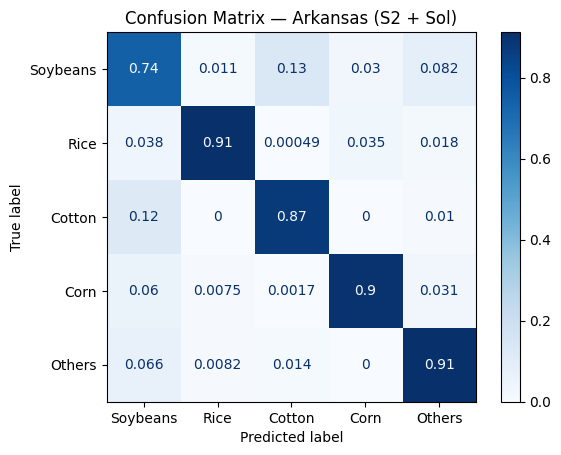

In [352]:
# Confusion Matrix Arkansas
labels = ["Soybeans", "Rice", "Cotton", "Corn", "Others"]
cm = confusion_matrix(y_test_a, y_pred_a,labels=[4,3,2,1,0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,display_labels=labels)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix — Arkansas (S2 + Sol)')
plt.show()


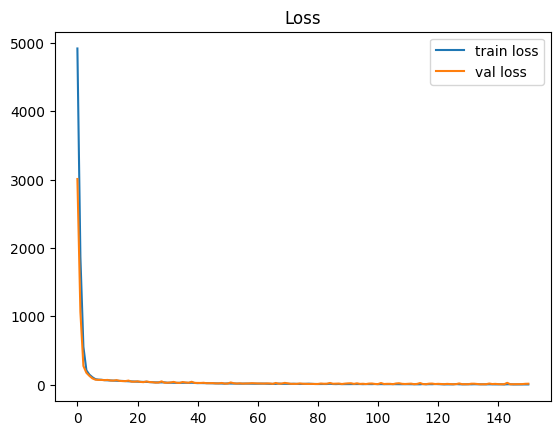

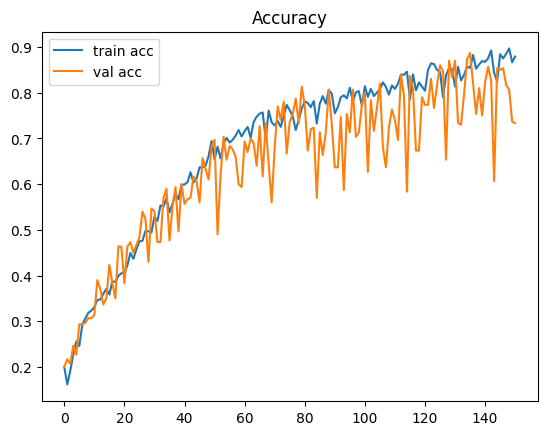

In [340]:
# Learning plots
plt.plot(history_a.history["loss"], label="train loss")
plt.plot(history_a.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history_a.history["accuracy"], label="train acc")
plt.plot(history_a.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()

## California — S2 + Sol

In [341]:
# Séparer X et y California
df_c_x = df_c.drop(columns=['crop_label', 'crop_name'])
df_c_y = df_c[['crop_name', 'crop_label']].copy()

# Encoder les classes California
label_map_c = {'Grapes': 0, 'Rice': 1, 'Alfalfa': 2, 'Almonds': 3, 'Pistachios': 4, 'Others': 5}
df_c_y['crop_label'] = df_c['crop_name'].map(label_map_c)
y_c = df_c_y['crop_label'].values

In [342]:
# Reshape X_time California
X_time_c = df_c_x[[col for col in df_c_x.columns if '_T' in col and col.startswith('B')]].values
X_time_c = X_time_c.reshape(-1, 36, 10)

# Sol uniquement (18 features)
X_static_c = df_c_x[soil_cols].values

print('X_time shape:', X_time_c.shape)
print('X_static shape:', X_static_c.shape)



X_time shape: (9996, 36, 10)
X_static shape: (9996, 3)


In [343]:
mask_time_c = (X_time_c != 0).astype(float)

In [344]:
X_max = X_time_c.max(axis=(0, 1), keepdims=True)

with np.errstate(invalid='ignore', divide='ignore'):
    X_time_c = np.where(
        X_max == 0,
        0,
        X_time_c / X_max
    )

X_static_max = X_static_c.max(axis=0, keepdims=True)

with np.errstate(invalid='ignore', divide='ignore'):
    X_static_c = np.where(
        X_static_max == 0,
        0,
        X_static_c / X_static_max
    )

In [345]:
# Split California — stratifié par classe (300 échantillons/classe pour train+val)

(X_time_train_c, X_time_val_c, X_time_test_c,
 X_static_train_c, X_static_val_c, X_static_test_c,
 y_train_c, y_val_c, y_test_c,
 mask_train_c, mask_val_c, mask_test_c) = split_par_classe(
    df_c, X_time_c, X_static_c, y_c, mask_time_c,
    n_per_class=300, val_ratio=0.2, random_state=42
)

print('Train:', X_time_train_c.shape, '| Val:', X_time_val_c.shape, '| Test:', X_time_test_c.shape)

Train: (1440, 36, 10) | Val: (360, 36, 10) | Test: (8196, 36, 10)


In [346]:
# Build + compile California
model_c = build_MCTNet(input_shape=(36, 10), static_shape=(3,), num_classes=6)
model_c.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_c.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_63      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_21 (Lambda)  │ (None, 36, 10)    │          0 │ input_layer_63[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_64      │ (None, 36, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_42         │ (None, 36, 10)    │          0 │ lambda_21[0][0],  │
│ (Multiply)          │                   │            │ input_layer_64[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_168 (Conv1D) │ (None, 36, 10)    │        310 │ multiply_42[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 10)        │          0 │ conv1d_168[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_42          │ (None, 10, 1)     │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_169 (Conv1D) │ (None, 10, 1)     │          3 │ reshape_42[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 10, 1)     │          0 │ conv1d_169[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_43          │ (None, 1, 10)     │          0 │ activation_21[0]… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_43         │ (None, 36, 10)    │          0 │ conv1d_168[0][0], │
│ (Multiply)          │                   │            │ reshape_43[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_210 (Add)       │ (None, 36, 10)    │          0 │ multiply_43[0][0… │
│                     │                   │            │ input_layer_63[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 36, 10)    │      2,160 │ add_210[0][0],    │
│ (MultiHeadAttentio… │                   │            │ add_210[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_254         │ (None, 36, 10)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_170 (Conv1D) │ (None, 36, 10)    │        310 │ input_layer_63[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_212 (Add)       │ (None, 36, 10)    │          0 │ add_210[0][0],    │
│                     │                   │            │ dropout_254[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 36, 10)    │         40 │ conv1d_170[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 36, 10)    │         20 │ add_212[0][0]     │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 61,999 (242.18 KB)

 Trainable params: 61,719 (241.09 KB)

 Non-trainable params: 280 (1.09 KB)

In [347]:
# Training California
history_c = model_c.fit(
    [X_time_train_c, mask_train_c, X_static_train_c], y_train_c,
    validation_data=([X_time_val_c, mask_val_c, X_static_val_c], y_val_c),
    epochs=200,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step - accuracy: 0.5924 - loss: 1.0996 - val_accuracy: 0.2528 - val_loss: 1.7237
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8014 - loss: 0.5992 - val_accuracy: 0.2833 - val_loss: 1.6980
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8542 - loss: 0.4788 - val_accuracy: 0.3250 - val_loss: 1.4947
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8840 - loss: 0.3807 - val_accuracy: 0.5361 - val_loss: 1.0806
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8806 - loss: 0.3602 - val_accuracy: 0.6083 - val_loss: 0.9982
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8840 - loss: 0.3319 - val_accuracy: 0.5778 - val_loss: 0.9948
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8931 - loss: 0.3218 - val_accuracy: 0.7889 - val_loss: 0.6129
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9174 - loss: 0.2686 - val_accuracy: 0

In [348]:
# Evaluation California
y_pred_c = np.argmax(model_c.predict([X_time_test_c, mask_test_c, X_static_test_c]), axis=1)

oa_c  = accuracy_score(y_test_c, y_pred_c)
f1_c  = f1_score(y_test_c, y_pred_c, average='macro')
kap_c = cohen_kappa_score(y_test_c, y_pred_c)

print('CALIFORNIA — S2 + Sol')
print(f'OA    : {oa_c:.4f}')
print(f'F1    : {f1_c:.4f}')
print(f'Kappa : {kap_c:.4f}')


labels_c = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
print(classification_report(y_test_c, y_pred_c, target_names=labels_c))

257/257 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
CALIFORNIA — S2 + Sol
OA    : 0.9272
F1    : 0.8941
Kappa : 0.9027
              precision    recall  f1-score   support

      Grapes       0.90      0.89      0.90      1710
        Rice       0.98      1.00      0.99      1721
     Alfalfa       0.97      0.95      0.96       664
     Almonds       0.69      0.84      0.76       493
  Pistachios       0.72      0.95      0.82       328
      Others       0.98      0.92      0.95      3280

    accuracy                           0.93      8196
   macro avg       0.87      0.92      0.89      8196
weighted avg       0.93      0.93      0.93      8196



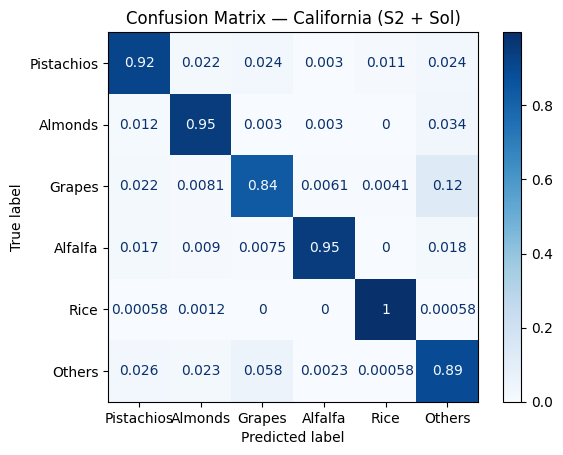

In [354]:
# Confusion Matrix California
labels = ["Pistachios","Almonds","Grapes", "Alfalfa","Rice", "Others"]
cm_c = confusion_matrix(y_test_c, y_pred_c,labels=[5,4,3,2,1,0])
cm_norm_c = cm_c.astype(float) / cm_c.sum(axis=1, keepdims=True)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm_c,display_labels=labels)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix — California (S2 + Sol)')
plt.show()


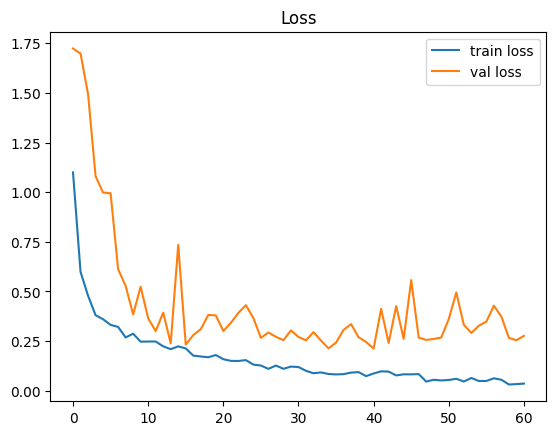

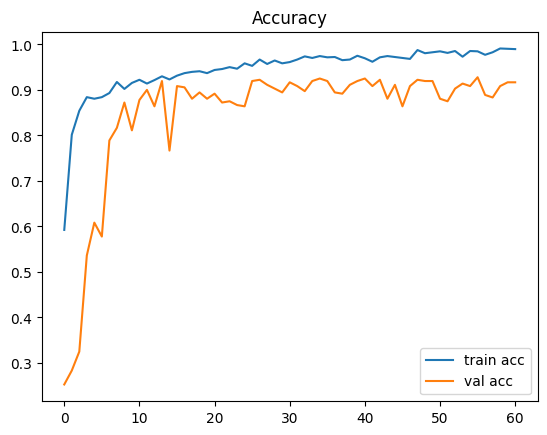

In [350]:
# Learning plots
plt.plot(history_c.history["loss"], label="train loss")
plt.plot(history_c.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history_c.history["accuracy"], label="train acc")
plt.plot(history_c.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()